<a href="https://colab.research.google.com/github/Guisteim/MVP_PUC/blob/MVP_Machine_Learn/MVP_PETR4_forecast_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Previsão de Preço da PETR4 (B3)

**Disciplina:** Machine Learning & Analytics  
**Tarefa:** Prever o próximo preço de fechamento diário (**t+1**) da ação **PETR4** usando dados históricos do dataset utilizado no ultimo MVP.  
**Dataset (URL):** `https://github.com/Guisteim/MVP_PUC/raw/refs/heads/MVP_Machine_Learn/bovespa_stocks_PETR4.csv`

Utilizei o dataset - https://www.kaggle.com/datasets/andrewmvd/brazilian-stock-market/data onde retirei somente o historico da ação PETR4.

## Checklist — Definição do Problema
- **Descrição:** previsão do preço de fechamento da PETR4 no dia **t+1** (regressão, série temporal).  
- **Tipo:** aprendizado supervisionado (regressão / forecasting de curto prazo).  
- **Premissas/Hipóteses:**
  - A dinâmica intrínseca de preços depende de valores passados (lags/rolling).  
  - Efeitos de calendário (dia da semana/mês) podem capturar sazonalidade fraca.  
- **Restrições:** usar somente informações disponíveis até **t** (evitar vazamento).  
- **Atributos:** Data/Date, Open, High, Low, Close, Volume, Symbol.

## 1) Setup e Importações

In [1]:
# Reprodutibilidade e bibliotecas
import os, sys, math, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

# Tentativa de usar XGBoost (opcional). Se não estiver instalado, instala.
try:
    import xgboost as xgb
    HAS_XGB = True
except Exception:
    HAS_XGB = False
    try:
        import subprocess, sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "xgboost"])
        import xgboost as xgb
        HAS_XGB = True
    except Exception:
        HAS_XGB = False

SEED = 42
np.random.seed(SEED)

## 2) Carga dos Dados (via URL)

In [2]:
URL = "https://github.com/Guisteim/MVP_PUC/raw/refs/heads/MVP_Machine_Learn/bovespa_stocks_PETR4.csv"

# Carrega CSV e tenta padronizar nomes de colunas de forma robusta
df = pd.read_csv(URL)

# Normaliza nomes
df.columns = [c.strip().replace(" ", "_") for c in df.columns]
lower_map = {c.lower(): c for c in df.columns}

# Função auxiliar para pegar coluna por nomes alternativos
def pick(colnames):
    for name in colnames:
        if name in df.columns:
            return name
        if name.lower() in lower_map:
            return lower_map[name.lower()]
    return None

date_col = pick(["Date","Data","date","data"])
close_col = pick(["Close","Adj_Close","close","fechamento"])
open_col  = pick(["Open","open","abertura"])
high_col  = pick(["High","high","max"])
low_col   = pick(["Low","low","min"])
vol_col   = pick(["Volume","Vol","volume"])
sym_col   = pick(["Symbol","Ticker","symbol","ticker"])

print("Colunas detectadas:")
print({"Date": date_col, "Open": open_col, "High": high_col, "Low": low_col, "Close": close_col, "Volume": vol_col, "Symbol": sym_col})

# Conversão de datas (robusta a timezone)
if date_col is None:
    raise ValueError("Coluna de data não encontrada. Verifique o CSV.")

# Tenta diferentes estratégias de parsing
dt = pd.to_datetime(df[date_col], errors="coerce", utc=True, infer_datetime_format=True)
if dt.isna().mean() > 0.5:
    # fallback para formato ISO misto
    dt = pd.to_datetime(df[date_col], errors="coerce", format="ISO8601", utc=True)

df["_Date"] = dt
# Converte para horário local SP e remove timezone para facilitar modelagem
try:
    df["_Date"] = df["_Date"].dt.tz_convert("America/Sao_Paulo").dt.tz_localize(None)
except Exception:
    df["_Date"] = df["_Date"].dt.tz_localize(None)

# Mantém somente as colunas relevantes disponíveis
keep = ["_Date"]
for c in [open_col, high_col, low_col, close_col, vol_col, sym_col]:
    if c is not None and c in df.columns:
        keep.append(c)
df = df[keep].dropna().sort_values("_Date").reset_index(drop=True)

df.rename(columns={"_Date": "Date", close_col: "Close", open_col: "Open", high_col: "High", low_col: "Low", vol_col: "Volume"}, inplace=True)

print("\nAmostra:")
display(df.head(10))
print("\nShape:", df.shape)

Colunas detectadas:
{'Date': 'Date', 'Open': 'Open', 'High': 'High', 'Low': 'Low', 'Close': 'Close', 'Volume': 'Volume', 'Symbol': 'Symbol'}

Amostra:


,Date,Open,High,Low,Close,Volume,Symbol
0,2010-01-03 22:00:00,36.950001,37.320000,36.820000,37.320000,13303600.0,PETR4
1,2010-01-04 22:00:00,37.380001,37.430000,36.799999,37.000000,21396400.0,PETR4
2,2010-01-05 22:00:00,36.799999,37.500000,36.799999,37.500000,18720600.0,PETR4
3,2010-01-06 22:00:00,37.270000,37.450001,37.070000,37.150002,10964600.0,PETR4
4,2010-01-07 22:00:00,37.160000,37.389999,36.860001,36.950001,14624200.0,PETR4
5,2010-01-10 22:00:00,37.209999,37.340000,36.619999,36.830002,15317700.0,PETR4
6,2010-01-11 22:00:00,36.590000,36.680000,36.040001,36.360001,14886200.0,PETR4
7,2010-01-12 22:00:00,36.560001,36.740002,35.840000,36.299999,23228200.0,PETR4
8,2010-01-13 22:00:00,36.279999,36.459999,35.560001,35.669998,20073400.0,PETR4
9,2010-01-14 22:00:00,35.570000,36.099998,35.509998,35.750000,21169000.0,PETR4



Shape: (3511, 7)


## 3) Análise Exploratória (breve e objetiva)

Tipos:
Date      datetime64[ns]
Open             float64
High             float64
Low              float64
Close            float64
Volume           float64
Symbol            object
dtype: object

Valores ausentes (%):
Date      0.0
Open      0.0
High      0.0
Low       0.0
Close     0.0
Volume    0.0
Symbol    0.0
dtype: float64


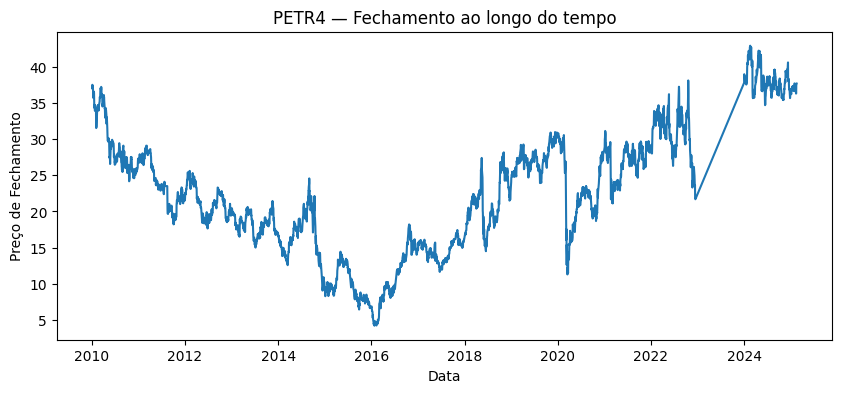

In [3]:
print("Tipos:")
print(df.dtypes)

print("\nValores ausentes (%):")
print(df.isna().mean().round(4) * 100)

# Gráfico simples do preço de fechamento
plt.figure(figsize=(10,4))
plt.plot(df["Date"], df["Close"])
plt.title("PETR4 — Fechamento ao longo do tempo")
plt.xlabel("Data")
plt.ylabel("Preço de Fechamento")
plt.show()

> **Observações da EDA (preencha após rodar):**
> - Tendência geral e volatilidade aparente.  
> - Eventuais quebras estruturais (ex.: períodos de crise).  
> - Presença/ausência de outliers e dados faltantes.

## 4) Feature Engineering (sem vazamento)

In [4]:
df_feat = df.copy()

# Cria retornos e log-retornos
df_feat["ret"] = df_feat["Close"].pct_change()
df_feat["logret"] = np.log1p(df_feat["ret"])

# Lags do preço/retornos (somente passado)
for k in [1,2,3,5,10,20]:
    df_feat[f"close_lag{k}"] = df_feat["Close"].shift(k)
    df_feat[f"ret_lag{k}"] = df_feat["ret"].shift(k)

# Médias móveis e volatilidade (rolling) — só usa passado
for w in [5,10,20]:
    df_feat[f"ma{w}"] = df_feat["Close"].rolling(w).mean()
    df_feat[f"std{w}"] = df_feat["Close"].rolling(w).std()

# Efeitos de calendário
df_feat["dow"] = df_feat["Date"].dt.weekday  # 0=segunda
df_feat["month"] = df_feat["Date"].dt.month

# TARGET: prever Close (t+1)
df_feat["y"] = df_feat["Close"].shift(-1)

# Remove linhas com NaN por causa de lags/rolling/shift
df_feat = df_feat.dropna().reset_index(drop=True)

print("Colunas finais:", df_feat.columns.tolist())
display(df_feat.head(5))

Colunas finais: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Symbol', 'ret', 'logret', 'close_lag1', 'ret_lag1', 'close_lag2', 'ret_lag2', 'close_lag3', 'ret_lag3', 'close_lag5', 'ret_lag5', 'close_lag10', 'ret_lag10', 'close_lag20', 'ret_lag20', 'ma5', 'std5', 'ma10', 'std10', 'ma20', 'std20', 'dow', 'month', 'y']


,Date,Open,High,Low,Close,Volume,Symbol,ret,logret,close_lag1,...,ret_lag20,ma5,std5,ma10,std10,ma20,std20,dow,month,y
0,2010-02-02 22:00:00,34.049999,34.180000,33.730000,34.040001,16091200.0,PETR4,-0.001759,-0.001761,34.099998,...,-0.008574,34.243999,0.226341,34.376,0.457632,35.4600,1.223206,1,2,32.299999
1,2010-02-03 22:00:00,33.840000,33.939999,32.119999,32.299999,24280300.0,PETR4,-0.051116,-0.052469,34.040001,...,0.013514,33.781999,0.834098,34.061,0.670729,35.2000,1.315903,2,2,31.520000
2,2010-02-04 22:00:00,31.799999,32.270000,30.719999,31.520000,29033800.0,PETR4,-0.024149,-0.024445,32.299999,...,-0.009333,33.252000,1.259412,33.780,1.035138,34.9185,1.469971,3,2,31.740000
3,2010-02-07 22:00:00,31.799999,32.259998,31.420000,31.740000,18684700.0,PETR4,0.006980,0.006955,31.520000,...,-0.005384,32.740000,1.247157,33.479,1.152692,34.6580,1.550452,6,2,32.240002
4,2010-02-08 22:00:00,32.200001,32.680000,32.099998,32.240002,18104200.0,PETR4,0.015753,0.015630,31.740000,...,-0.003248,32.368000,0.991222,33.313,1.203726,34.4285,1.551737,0,2,32.639999


> **Nota:** Toda transformação usa apenas informações **até t**, e o alvo é **Close (t+1)**. Assim evitamos **vazamento de dados**.

## 5) Divisão Treino/Teste e Validação Temporal

In [5]:
# Ordena por data por garantia
df_feat = df_feat.sort_values("Date").reset_index(drop=True)

# Separa X, y
target = "y"
cols_drop = ["Date", "y"]
X = df_feat.drop(columns=cols_drop, errors="ignore")
y = df_feat[target].values

# Split: holdout final = últimos 20% para teste
n = len(df_feat)
test_size = int(0.2 * n)
X_train, X_test = X.iloc[:-test_size], X.iloc[-test_size:]
y_train, y_test = y[:-test_size], y[-test_size:]

print("Tamanhos:", len(X_train), len(X_test))

Tamanhos: 2792 697


## 6) Baselines (Naive e Média Móvel)

In [6]:
# Baseline 1: Naive (y_{t+1} = Close_t)
naive_pred_test = df_feat["Close"].shift(1).iloc[-test_size:].values
mae_naive = mean_absolute_error(y_test, naive_pred_test)
# Calculate RMSE manually for compatibility
rmse_naive = mean_squared_error(y_test, naive_pred_test)
rmse_naive = np.sqrt(rmse_naive)

# Baseline 2: Média móvel de 5 dias (prevê t+1 como MA5_t)
ma5 = df_feat["Close"].rolling(5).mean().shift(1)  # MA até t
ma5_pred_test = ma5.iloc[-test_size:].values
mae_ma5 = mean_absolute_error(y_test, ma5_pred_test)
# Calculate RMSE manually for compatibility
rmse_ma5 = mean_squared_error(y_test, ma5_pred_test)
rmse_ma5 = np.sqrt(rmse_ma5)

print(f"Baseline Naive — MAE: {mae_naive:.4f} | RMSE: {rmse_naive:.4f}")
print(f"Baseline MA5   — MAE: {mae_ma5:.4f} | RMSE: {rmse_ma5:.4f}")

Baseline Naive — MAE: 0.8080 | RMSE: 1.3794
Baseline MA5   — MAE: 1.0763 | RMSE: 1.6882


## 7) Modelagem, Cross-Validation temporal e Otimização de Hiperparâmetros

In [7]:
tscv = TimeSeriesSplit(n_splits=5)

results = []

# 7.1) Ridge (com padronização)
pipe_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(random_state=SEED))
])

param_ridge = {
    "model__alpha": [0.01, 0.1, 1.0, 10.0, 50.0]
}

# Remove 'Symbol' column as it's not numeric and not needed for modeling
X_train_numeric = X_train.drop(columns=["Symbol"], errors="ignore")
X_test_numeric = X_test.drop(columns=["Symbol"], errors="ignore")


gcv_ridge = GridSearchCV(pipe_ridge, param_grid=param_ridge, scoring="neg_mean_absolute_error",
                         cv=tscv, n_jobs=-1, refit=True)
gcv_ridge.fit(X_train_numeric, y_train)

y_pred_ridge = gcv_ridge.predict(X_test_numeric)
# Calculate RMSE manually for compatibility
rmse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(rmse_ridge)
results.append(("Ridge", gcv_ridge.best_params_, mean_absolute_error(y_test, y_pred_ridge),
                rmse_ridge))

# 7.2) RandomForest
rf = RandomForestRegressor(random_state=SEED, n_estimators=400, max_depth=None, min_samples_leaf=2, n_jobs=-1)
param_rf = {
    "n_estimators": [300, 500],
    "max_depth": [None, 6, 10],
    "min_samples_leaf": [1, 2, 4]
}
gcv_rf = GridSearchCV(rf, param_grid=param_rf, scoring="neg_mean_absolute_error",
                      cv=tscv, n_jobs=-1, refit=True)
gcv_rf.fit(X_train_numeric, y_train)

y_pred_rf = gcv_rf.predict(X_test_numeric)
# Calculate RMSE manually for compatibility
rmse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(rmse_rf)
results.append(("RandomForest", gcv_rf.best_params_, mean_absolute_error(y_test, y_pred_rf),
                rmse_rf))

# 7.3) XGBoost (se disponível)
if HAS_XGB:
    xgbr = xgb.XGBRegressor(
        random_state=SEED,
        objective="reg:squarederror",
        n_estimators=600,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        max_depth=6,
        n_jobs=-1,
    )
    param_xgb = {
        "n_estimators": [400, 800],
        "max_depth": [4, 6, 8],
        "learning_rate": [0.03, 0.05, 0.1],
        "subsample": [0.7, 0.9],
        "colsample_bytree": [0.7, 0.9]
    }
    gcv_xgb = GridSearchCV(xgbr, param_grid=param_xgb, scoring="neg_mean_absolute_error",
                           cv=tscv, n_jobs=-1, refit=True)
    gcv_xgb.fit(X_train_numeric, y_train)
    y_pred_xgb = gcv_xgb.predict(X_test_numeric)
    # Calculate RMSE manually for compatibility
    rmse_xgb = mean_squared_error(y_test, y_pred_xgb)
    rmse_xgb = np.sqrt(rmse_xgb)
    results.append(("XGBoost", gcv_xgb.best_params_, mean_absolute_error(y_test, y_pred_xgb),
                    rmse_xgb))
else:
    print("XGBoost indisponível — pulando este modelo.")

# Tabela de resultados
res_df = pd.DataFrame(results, columns=["Modelo","BestParams","MAE","RMSE"]).sort_values("MAE").reset_index(drop=True)
display(res_df)

,Modelo,BestParams,MAE,RMSE
0,Ridge,{'model__alpha': 0.1},1.061564,1.906495
1,RandomForest,"{'max_depth': 10, 'min_samples_leaf': 2, 'n_es...",2.112127,3.744134
2,XGBoost,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",2.640185,4.886643


## 8) Escolha do Melhor Modelo e Avaliação no Teste

Melhor por MAE: Ridge
Teste — Ridge:  MAE=1.0616 | RMSE=1.9065 | MAPE=3.07%
Baselines → Naive MAE=0.8080 / RMSE=1.3794  |  MA5 MAE=1.0763 / RMSE=1.6882


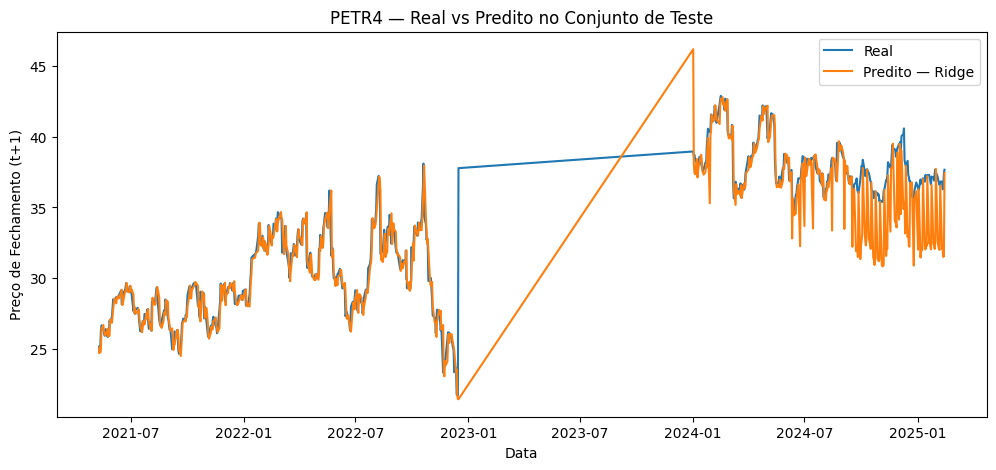

In [8]:
# Decide pelo menor MAE (poderia ser RMSE/MAPE conforme preferência)
best_row = res_df.iloc[0]
best_name = best_row["Modelo"]
print("Melhor por MAE:", best_name)

# Recupera o estimador treinado ideal para previsões e análise
if best_name == "Ridge":
    best_est = gcv_ridge.best_estimator_
    y_pred = gcv_ridge.predict(X_test_numeric)
elif best_name == "RandomForest":
    best_est = gcv_rf.best_estimator_
    y_pred = gcv_rf.predict(X_test_numeric)
else:
    best_est = gcv_xgb.best_estimator_
    y_pred = gcv_xgb.predict(X_test_numeric)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(rmse)
mape = np.mean(np.abs((y_test - y_pred) / np.maximum(1e-8, np.abs(y_test)))) * 100

print(f"Teste — {best_name}:  MAE={mae:.4f} | RMSE={rmse:.4f} | MAPE={mape:.2f}%")
print(f"Baselines → Naive MAE={mae_naive:.4f} / RMSE={rmse_naive:.4f}  |  MA5 MAE={mae_ma5:.4f} / RMSE={rmse_ma5:.4f}")

# Gráfico: Real vs Predito
dates_test = df_feat["Date"].iloc[-len(y_test):].values

plt.figure(figsize=(12,5))
plt.plot(dates_test, y_test, label="Real")
plt.plot(dates_test, y_pred, label=f"Predito — {best_name}")
plt.title("PETR4 — Real vs Predito no Conjunto de Teste")
plt.xlabel("Data"); plt.ylabel("Preço de Fechamento (t+1)")
plt.legend()
plt.show()

In [9]:
# PREVISÃO PARA O PRÓXIMO DIA ÚTIL (FECHAMENTO t+1)
import pandas as pd
import numpy as np
from pandas.tseries.offsets import BDay

# 1) Próxima data útil a partir da última data do dataset
last_date = pd.to_datetime(df_feat["Date"].iloc[-1])
next_business_day = last_date + BDay(1)

# 2) Vetor de features da última observação (usado para prever y_{t+1})
last_features_numeric = (
    df_feat
    .select_dtypes(include="number")
    .drop(columns=["y"], errors="ignore")
    .iloc[[-1]]
)

# 3) Alinha colunas com as usadas no treino/teste
cols_ref = None
if hasattr(X_test_numeric, "columns"):
    cols_ref = list(X_test_numeric.columns)
elif hasattr(best_est, "feature_names_in_"):
    cols_ref = list(best_est.feature_names_in_)

if cols_ref is not None:
    last_features_numeric = last_features_numeric.reindex(columns=cols_ref, fill_value=0.0)

# 4) Predição do fechamento do próximo dia útil
next_close_pred = float(best_est.predict(last_features_numeric)[0])

print(f"Próximo dia útil: {next_business_day.date()}")
print(f"Previsão de fechamento (t+1) — {best_name}: {next_close_pred:.2f}")


Próximo dia útil: 2025-02-14
Previsão de fechamento (t+1) — Ridge: 37.43


## 9) Conclusões e Próximos Passos

- **Modelo vencedor:** escolhido com base na menor **MAE** em teste (ver tabela e impressão acima).  
- **Comparação com baselines:** o modelo deve **superar Naive e MA5** para justificar seu uso.  
- **Melhorias sugeridas:**
  - Incluir **variáveis exógenas** (ex.: Brent, USD/BRL, Ibovespa futuro).  
  - Ajustar janelas de *lags* e *rollings* conforme otimização de hiperparâmetros.  
  - Avaliar **modelos específicos de séries temporais** (ARIMA, Prophet) e **arquiteturas profundas** (LSTM/Temporal CNN).  
  - Validar janelas **walk-forward** (treina → valida → avança) para maior realismo.

## 10) Boas Práticas e Reprodutibilidade
- Seed fixada (`SEED=42`).  
- Validação temporal (`TimeSeriesSplit`) para evitar vazamento.  
- **Pipelines** foram utilizados (Ridge) e **grids** documentados.  
- Código segmentado e textualização das decisões.  
- Métricas: **MAE, RMSE e MAPE** reportadas.